<a href="https://colab.research.google.com/github/HMS-Cleveland/Questionary_logist/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


验证集 AUC = 0.712
diagnosis
0    0.970801
1    0.029199
Name: proportion, dtype: float64


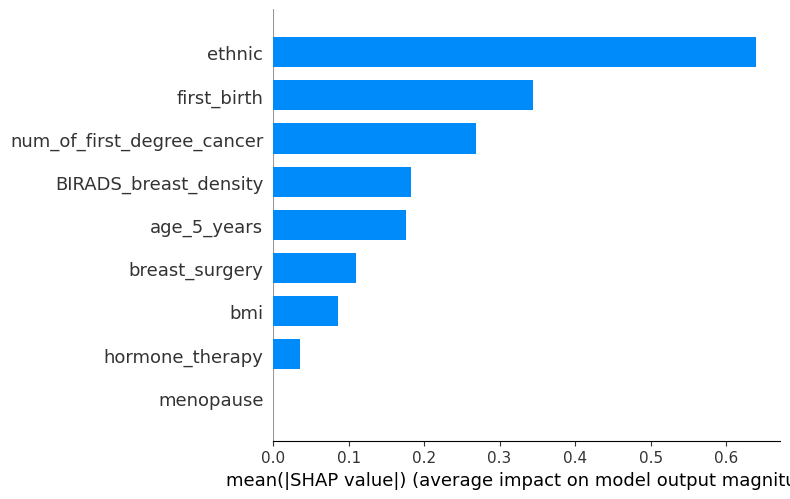

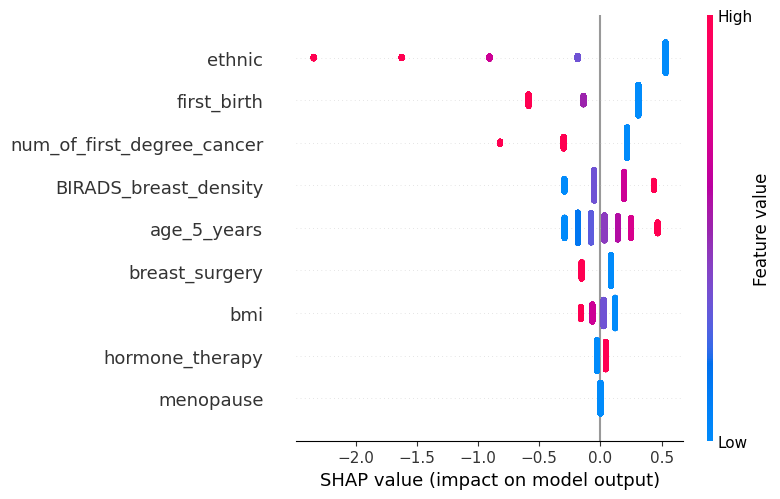

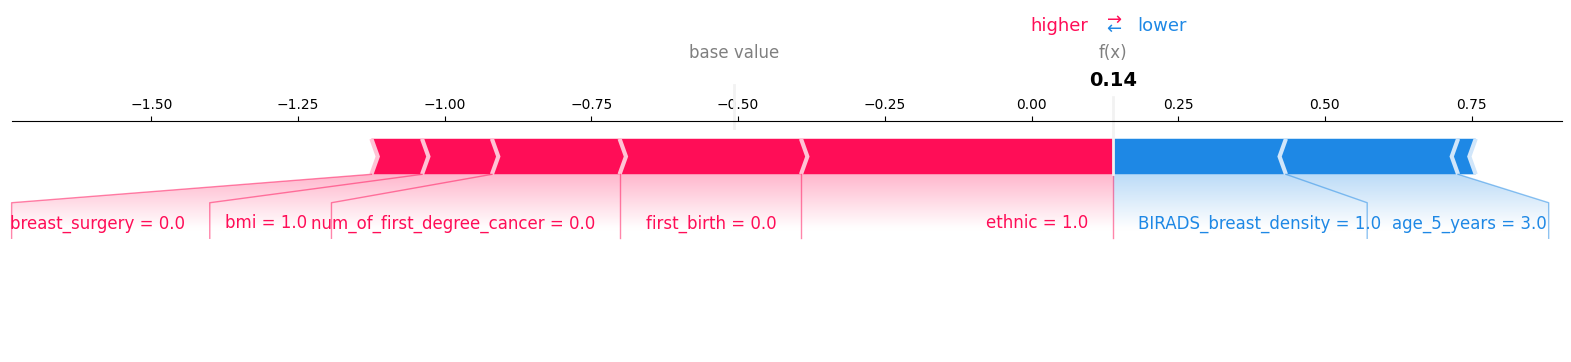

测试集 AUC = 0.709
              precision    recall  f1-score   support

           0       0.99      0.52      0.68     16963
           1       0.03      0.78      0.06       329

    accuracy                           0.53     17292
   macro avg       0.51      0.65      0.37     17292
weighted avg       0.97      0.53      0.67     17292

准确率 = 0.526
{'0': {'precision': 0.9919228180390397, 'recall': 0.5212521370040677, 'f1-score': 0.683386791359122, 'support': 16963.0}, '1': {'precision': 0.03067557889711148, 'recall': 0.7811550151975684, 'f1-score': 0.05903296198461008, 'support': 329.0}, 'accuracy': 0.5261970853573907, 'macro avg': {'precision': 0.5112991984680756, 'recall': 0.651203576100818, 'f1-score': 0.371209876671866, 'support': 17292.0}, 'weighted avg': {'precision': 0.9736339942085, 'recall': 0.5261970853573907, 'f1-score': 0.6715077484569583, 'support': 17292.0}}
Sensitivity (Recall for class 1) = 0.781
Specificity (Recall for class 0) = 0.521
该个体绝对风险 = 48.414%

【风险因素OR值排名

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, recall_score

!pip install shap
import shap


#指定要读取的列号（从0开始数）
usecols = [0,1,2,3,5,6,7,8,11,12,14]
#给这些列命名
names = ['menopause', 'age_5_years', 'BIRADS_breast_density','ethnic','bmi',
         'first_birth','num_of_first_degree_cancer','breast_surgery',
         'hormone_therapy','diagnosis','is_train']


#读取
data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
           sep=r'\s+',
           header=None,
           usecols=usecols,
           names=names)

# 处理未知值（编码9表示未知）
data.replace(9, np.nan, inplace=True)                     # 将9替换为NaN
# 计算每行缺失值个数
missing_per_row = data.isnull().sum(axis=1)
# 保留缺失值 ≤ 3 的行
data = data[missing_per_row <= 0].copy()



#按 is_train 拆分
X_train = data[data['is_train'] == 1].drop(columns=['diagnosis', 'is_train'])
y_train = data[data['is_train'] == 1]['diagnosis']

X_test  = data[data['is_train'] == 0].drop(columns=['diagnosis', 'is_train'])
y_test  = data[data['is_train'] == 0]['diagnosis']



# 6. 第二次切分：80% 再拆 8:1 → 训练:验证 ≈ 72% : 8%
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.125,       # 0.125 * 80% = 10% 验证集
    stratify=y_train,
    random_state=42
)

# 应用预处理
X_train_processed = X_train.values  # 训练集拟合转换
X_test_processed = X_test.values         # 测试集仅转换

# 7. 训练 Logistic 回归
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced'
)
model.fit(X_train_processed, y_train)

# 8. 验证集评估（调参用）
val_prob = model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, val_prob)
print(f'验证集 AUC = {val_auc:.3f}')

print(y_train.value_counts(normalize=True))

# 使用 LinearExplainer（专为线性模型优化）
explainer = shap.LinearExplainer(
    model,
    X_train_processed,  # 训练集数据
    feature_names=X_train.columns.tolist()  # 特征名称
)
###########################################################
# 计算测试集样本的 SHAP 值
shap_values = explainer.shap_values(X_test_processed)

# === 全局特征贡献（所有样本） ===
# 1. 特征重要性条形图（按平均|SHAP|排序）
shap.summary_plot(shap_values, X_test_processed, feature_names=X_train.columns, plot_type="bar")

# 2. 蜂群图（展示特征值与贡献的关系）
shap.summary_plot(shap_values, X_test_processed, feature_names=X_train.columns)

# === 局部特征贡献（单个样本） ===
# 3. 瀑布图（解释单个预测）
sample_idx = 0  # 选择一个样本
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx, :],
    X_test_processed[sample_idx, :],
    feature_names=X_train.columns,
    matplotlib=True  # 在 Colab 中显示
)
############################################################
# 9. 测试集最终评估（锁定模型后）
test_prob = model.predict_proba(X_test)[:, 1]
val_pred = model.predict(X_test)
test_auc = roc_auc_score(y_test, test_prob)
print(f'测试集 AUC = {test_auc:.3f}')
print(classification_report(y_test, (test_prob > 0.5).astype(int)))


y_true = y_test
accuracy = accuracy_score(y_test,val_pred)
print("============")
print(f"准确率 = {accuracy:.3f}")

# 用你已有的测试集标签和预测结果
report = classification_report(
    y_test,
    val_pred,           # 你之前已经用 0.5 阈值得到的硬标签
    output_dict=True    # 返回字典
)

# 打印看看
print(report)

# 灵敏度（召回率）= 真阳性率
sensitivity = report['1']['recall']
print(f"Sensitivity (Recall for class 1) = {sensitivity:.3f}")

# 特异性 = 真阴性率 = Recall for class 0
specificity = report['0']['recall']
print(f"Specificity (Recall for class 0) = {specificity:.3f}")

# 10. 相对风险(OR) 与 绝对风险
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'log_OR': model.coef_[0],
    'OR': np.exp(model.coef_[0])
}).sort_values('OR', ascending=False)


# 11. 给某个人计算 5 年绝对风险示例
# person 为 1 行 0/1 特征向量
person = np.array([[1, 0, 1, 0, 0, 1, 0, 1, 0]])  # 示例
logit = model.decision_function(person)[0]
abs_risk = 1 / (1 + np.exp(-logit))
print(f'该个体绝对风险 = {abs_risk:.3%}')


# 特征重要性解读（医疗决策关键！）
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Odds_Ratio': np.exp(model.coef_[0])
}).sort_values('Odds_Ratio', ascending=False).reset_index(drop=True)

print("\n【风险因素OR值排名】")
print(coef_df.head(10))


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. 构造交互
poly = PolynomialFeatures(
        interaction_only=True,
        include_bias=False)   # 只保留交叉项，不保留平方项

# 2. 建立 Pipeline：先交互 → 再 L1 逻辑回归
pipe = Pipeline([
    ('poly', poly),
    ('clf', LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=0.5,            # 用交叉验证调 C
            max_iter=1000,
            class_weight='balanced'))
])

pipe.fit(X_train, y_train)

# 3. 提取非零系数及其名称
coef_full = pipe.named_steps['clf'].coef_.ravel()
feat_names = pipe.named_steps['poly'].get_feature_names_out(X_train.columns)
interaction_df = pd.DataFrame({
    'feature': feat_names,
    'coef': coef_full,
    'OR': np.exp(coef_full)
}).query('coef != 0').sort_values('OR', ascending=False)

print('\n【非零交互项 OR 值】')
print(interaction_df.head(20))


【非零交互项 OR 值】
                                             feature      coef        OR
8                                    hormone_therapy  0.627525  1.872969
33                             ethnic breast_surgery  0.468181  1.597086
16                         menopause hormone_therapy  0.464393  1.591048
0                                          menopause  0.337126  1.400916
2                              BIRADS_breast_density  0.224437  1.251618
42         num_of_first_degree_cancer breast_surgery  0.216441  1.241650
39            first_birth num_of_first_degree_cancer  0.206911  1.229873
32                 ethnic num_of_first_degree_cancer  0.186522  1.205052
10                   menopause BIRADS_breast_density  0.164321  1.178592
29             BIRADS_breast_density hormone_therapy  0.144627  1.155608
40                        first_birth breast_surgery  0.134993  1.144528
22                        age_5_years breast_surgery  0.083199  1.086758
27  BIRADS_breast_density num_of_firs

In [ ]:
th = 0.5   # 可调阈值

poly = PolynomialFeatures(interaction_only=True, include_bias=False)

pipe = Pipeline([
    ('poly', poly),
    ('clf', LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=0.5,
            max_iter=1000,
            class_weight='balanced'))
])

pipe.fit(X_train, y_train)

# 提取系数和特征名
coef_arr = pipe.named_steps['clf'].coef_.ravel()
feat_names = pipe.named_steps['poly'].get_feature_names_out(X_train.columns)

coef_df = pd.DataFrame({
    'feature': feat_names,
    'log_OR': coef_arr,
    'OR': np.exp(coef_arr)
}).query('log_OR != 0')      # 先把系数为 0 的过滤掉，避免 log_OR==0 误判

# 选出绝对值较大的交互项（名字中含空格即为交互项）
high_imp = coef_df.query('abs(log_OR) > @th and feature.str.contains(" ")')['feature'].tolist()

print(f'\n选出的高重要性交互项（|log OR| > {th}）：')
print(high_imp)

# -------------------------------------------------------
# 2. 把交互特征追加到原始矩阵
# -------------------------------------------------------
# 用同一个 poly 对象生成完整交互矩阵
poly_full = PolynomialFeatures(interaction_only=True, include_bias=False).fit(X_train)
all_names = poly_full.get_feature_names_out(X_train.columns)

def add_interactions(X):
    Xt = poly_full.transform(X)
    # 仅保留我们选出的高重要性交互列
    mask = [f in high_imp for f in all_names]
    return np.hstack([X.values, Xt[:, mask]])

X_train_int = add_interactions(X_train)
X_val_int   = add_interactions(X_val)
X_test_int  = add_interactions(X_test)

# 新特征名
new_features = list(X_train.columns) + high_imp
print(f'\n最终训练特征数：{len(new_features)}')

# -------------------------------------------------------
# 3. 重新训练最终模型
# -------------------------------------------------------
final_model = LogisticRegression(
        penalty='l2',
        solver='liblinear',
        C=1.0,
        max_iter=1000,
        class_weight='balanced')

final_model.fit(X_train_int, y_train)

# 验证集 AUC
val_prob = final_model.predict_proba(X_val_int)[:, 1]
print(f'\n验证集 AUC = {roc_auc_score(y_val, val_prob):.3f}')

# 测试集指标
test_prob = final_model.predict_proba(X_test_int)[:, 1]
test_pred = (test_prob > 0.5).astype(int)


accuracy = accuracy_score(y_test,test_pred)
print("============")
print(f"准确率 = {accuracy:.3f}")

print('\n测试集性能：')
print(classification_report(y_test, test_pred))

# 灵敏度、特异度
sens = recall_score(y_test, test_pred, pos_label=1)
spec = recall_score(y_test, test_pred, pos_label=0)
print(f'\nSensitivity = {sens:.3f}')
print(f'Specificity = {spec:.3f}')

# -------------------------------------------------------
# 4. 可选：输出最终系数表（含交互）
# -------------------------------------------------------
final_coef = pd.DataFrame({
    'Feature': new_features,
    'log_OR' : final_model.coef_[0],
    'OR'     : np.exp(final_model.coef_[0])
}).sort_values('OR', ascending=False)

print('\n【最终模型系数（含交互）】')
print(final_coef.head(20))


选出的高重要性交互项（|log OR| > 0.5）：
['menopause ethnic', 'menopause breast_surgery', 'menopause hormone_therapy']

最终训练特征数：12

验证集 AUC = 0.712
准确率 = 0.526

测试集性能：
              precision    recall  f1-score   support

           0       0.99      0.52      0.68     16963
           1       0.03      0.78      0.06       329

    accuracy                           0.53     17292
   macro avg       0.51      0.65      0.37     17292
weighted avg       0.97      0.53      0.67     17292


Sensitivity = 0.781
Specificity = 0.521

【最终模型系数（含交互）】
                       Feature    log_OR        OR
2        BIRADS_breast_density  0.243663  1.275915
0                    menopause  0.190438  1.209779
1                  age_5_years  0.108663  1.114786
11   menopause hormone_therapy  0.036618  1.037297
8              hormone_therapy  0.036618  1.037297
4                          bmi -0.093045  0.911153
10    menopause breast_surgery -0.119897  0.887012
7               breast_surgery -0.119897  0.887012
3 

In [ ]:
# 导入网格搜索交叉验证工具
from sklearn.model_selection import GridSearchCV

# 定义超参数搜索空间
param_grid = {
    'C': [0.01, 0.1, 1, 10],     # 正则化强度（越小正则化越强）
    'penalty': ['l1', 'l2'],      # 正则化类型：L1（稀疏特征）或 L2（平滑权重）
    'solver': ['liblinear']       # 求解器：支持L1/L2的快速小数据集求解器
}

# 创建GridSearchCV对象
grid_search = GridSearchCV(
    # 基础模型：带平衡类别权重的逻辑回归（适合不平衡数据）
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,                  # 传入参数网格
    scoring='roc_auc',           # 评估指标：AUC-ROC（优于准确率，尤其对不平衡数据）
    cv=5,                        # 5折交叉验证（确保泛化性）
    n_jobs=-1                    # 使用所有CPU核心加速计算
)

# 执行网格搜索（核心步骤）
grid_search.fit(X_train_processed, y_train)  # 在训练集上拟合

# 输出最优结果
print(f"最优参数: {grid_search.best_params_}")  # 如 {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
print(f"最优AUC: {grid_search.best_score_:.3f}")  # 交叉验证下的平均AUC（非测试集）

最优参数: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
最优AUC: 0.708
